# Pandas Practice 3 (Bike Share Data)

As a data scientist, you don't always have to invent the wheel from scratch. The great advantage of Python is that smart people before you spend a lot of energy on making life easier for the next programers. So please, make your life easier and use code that has already been implemented, don't call it "copying" but "friendly borrowing" of other people's code. If you copy whole functions or great graphs in the future, don't forget to give props to the inventor!

So for this exercise, too, if you get stuck at any point, look at good solutions from others and learn a lot from them about how to solve these problems even better.
Here are two good resources for small code snippet which can be very helpful when dealing with DataFrames:

- [Sebastian Raschkas "Things in Pandas I Wish I'd Known Earlier"](https://nbviewer.jupyter.org/github/rasbt/python_reference/blob/master/tutorials/things_in_pandas.ipynb)
- [Helpful Python Code Snippets for Data Exploration in Pandas](https://medium.com/@msalmon00/helpful-python-code-snippets-for-data-exploration-in-pandas-b7c5aed5ecb9)
- [Manipulating tabular data with Pandas](https://neuroimaging-data-science.org/content/004-scipy/002-pandas.html)


**By the end of this session you should be able to**
- Explore data with Pandas to answer conceptual questions
- Write chained commands for efficient one-liners



In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv('data/bike_share_201402_trip_data.csv')

How many observations are there?

In [14]:
df.dropna(inplace=True)
df.shape

(137885, 11)

Change the columns to be pythonic:

- lowercase 
- replace " " with `_` as a separator
- replace "#" with `num` 


In [15]:
print(df.columns)

df.rename(
    columns=lambda x:\
          x.lower()\
            .replace(" ", "_")\
            .replace("#", "num_")\
            .rstrip("_"),
        inplace=True
)

print(df.columns)

Index(['Trip ID', 'Duration', 'Start Date', 'Start Station', 'Start Terminal',
       'End Date', 'End Station', 'End Terminal', 'Bike #',
       'Subscription Type', 'Zip Code'],
      dtype='object')
Index(['trip_id', 'duration', 'start_date', 'start_station', 'start_terminal',
       'end_date', 'end_station', 'end_terminal', 'bike_num',
       'subscription_type', 'zip_code'],
      dtype='object')


How many types of subscription options are there? What are the different subscription types?

In [16]:
df["subscription_type"].unique()

array(['Subscriber', 'Customer'], dtype=object)

What is the frequency of each subscription option?

In [ ]:
subs_freq = df.groupby("subscription_type").size()
# subs = df["subscription_type"].value_counts() # Alternative
print(subs_freq)

subscription_type
Customer       24238
Subscriber    113647
dtype: int64


Please plot the frequency of each subscription option with a pie chart:

<Axes: >

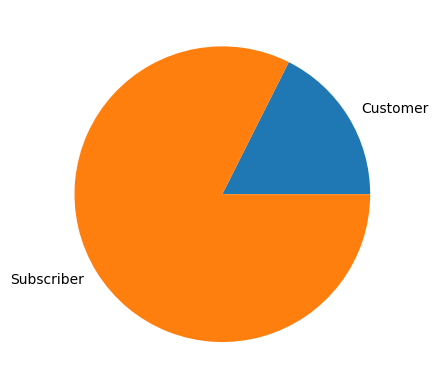

In [23]:
subs_freq.plot.pie()

Please plot the frequency of each subscription option with a bar chart:

<Axes: xlabel='subscription_type'>

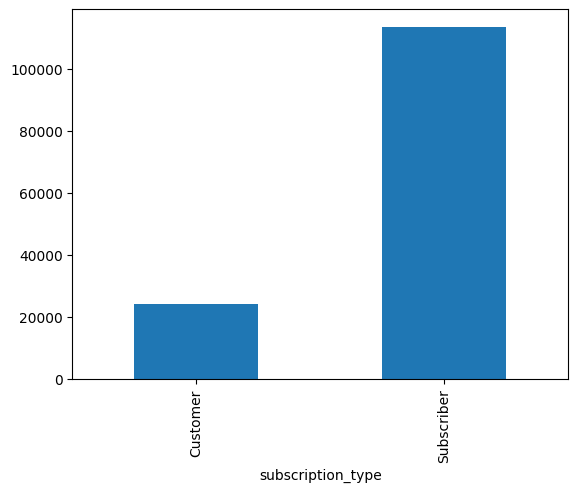

In [24]:
subs_freq.plot.bar()

Have a look at the start_station column: Which 10 stations occur most frequently?

In [18]:
df.groupby("start_station").size().sort_values(ascending=False)[:10]

start_station
San Francisco Caltrain (Townsend at 4th)         9677
Harry Bridges Plaza (Ferry Building)             6766
Embarcadero at Sansome                           5826
Market at Sansome                                5742
Temporary Transbay Terminal (Howard at Beale)    5021
San Francisco Caltrain 2 (330 Townsend)          4899
2nd at Townsend                                  4827
Market at 4th                                    4691
Steuart at Market                                4686
Townsend at 7th                                  4427
dtype: int64

Now look at the end_station column: Which 10 stations occur the least often?

In [19]:
df.groupby("end_station").size().sort_values(ascending=True)[:10]

end_station
Mezes Park                            5
San Jose Government Center           22
Broadway at Main                     54
Franklin at Maple                    90
San Antonio Shopping Center          91
San Mateo County Center             105
Redwood City Public Library         113
Castro Street and El Camino Real    129
Redwood City Medical Center         178
Broadway St at Battery St           196
dtype: int64

Create a table that has start_station segmented by subscription_type and include also the row/column margins (subtotals). If you are not sure how to do it, check out the documentation for `pd.crosstab()`.

In [26]:
pd.crosstab(
    df["start_station"],
    df["subscription_type"],
    margins=True
)

subscription_type,Customer,Subscriber,All
start_station,,,
2nd at Folsom,358,3349,3707
2nd at South Park,483,3923,4406
2nd at Townsend,722,4105,4827
5th at Howard,484,2029,2513
Adobe on Almaden,67,260,327
...,...,...,...
Townsend at 7th,452,3975,4427
University and Emerson,267,106,373
Washington at Kearney,432,911,1343


Let's look at the duration... Which unit do you think is used here?

How long is the shortest trip? How many are that short?

In [31]:
df["duration"].describe()

count    137885.000000
mean       1101.357370
std        6301.340291
min          60.000000
25%         344.000000
50%         520.000000
75%         768.000000
max      722236.000000
Name: duration, dtype: float64

In [36]:
df["duration"][df["duration"]==60].count()

np.int64(17)

In [47]:
df["duration"].quantile(q=[x/10 for x in range(11)])

0.0        60.0
0.1       239.0
0.2       309.0
0.3       376.0
0.4       445.0
0.5       520.0
0.6       602.0
0.7       702.0
0.8       856.0
0.9      1210.0
1.0    722236.0
Name: duration, dtype: float64

<Axes: ylabel='Frequency'>

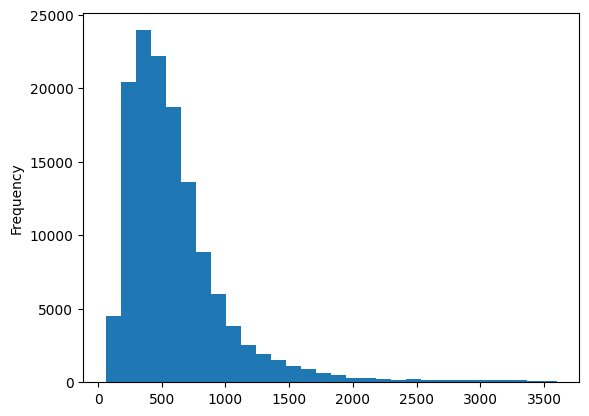

In [41]:
df["duration"][df["duration"]<3600].plot.hist(bins=30)

What do you think is going on with the short trips?

What is the longest trip?

How would you define a "long" trip? How many trips are "long" according to your definition?

Do the long durations seem reasonable? Why are they so long? What could it tell us about the users?

Plot the duration column.

Does this plot give any insights?

Select subsections of the data to make plots that provide more insights.

The Product Team would like all of the station names to be lower case and  with `_` as a separator

`South Van Ness at Market` -> `south_van_ness_at_market`  

**DO NOT USE A FOR LOOP. THEY ARE THE 👿**

In [54]:
df2 = df.copy()

df2["start_station"] = df2["start_station"].apply(
    lambda x: x.lower().replace(" ", "_")
)
df2["end_station"] = df2["end_station"].apply(
    lambda x: x.lower().replace(" ", "_")
)

Now take a timer and set it to 15 minutes. Take this time to explore the data guided by your own intuition or hypotheses…
> Time boxing is a helpful approach when working with a new dataset so you won't fall into any rabbit holes. 